In [1]:
import argparse
import os
import torch
import pandas as pd
from tqdm import tqdm
from pathlib import Path

# Set CUDA path as per original script
os.environ['CUDA_PATH'] = '/apps/compilers/cuda/13.2.1' 

import vcme
from vcme.utils import yeast_data, YeastMetadata
from vcme.marginals import MargEpistasis
from epikVC.models import GPModel, make_GP_model, load_GP_model

from itertools import combinations
def get_all_pairs(lst):
    """Returns all unique 2-element combinations from the list."""
    return list(combinations(lst, 2))

def flatten_list(matrix):
    """Flattens a 1-level nested list of lists."""
    return [item for sublist in matrix for item in sublist]

def get_pathway_snps(pwy):
    genes_in_pathway = pathway_genes[pwy]
    snp_list = [gene_snps[gene] for gene in genes_in_pathway]
    return flatten_list(snp_list)

def get_pathway_interaction(pwy0, pwy1):
    pw0_snps, pw1_snps = get_pathway_snps(pwy0), get_pathway_snps(pwy1)
    n_interactions = len(pw0_snps) * len(pw1_snps)
    ss = marg.get_gxg_interaction(pw0_snps, pw1_snps)
    
    return ss, ss/n_interactions



wd = '/blue/juannanzhou/juannanzhou/vcme_project/'
checkpoint_path = wd + 'model_checkpoints/37C_r2_threshold=None_MAF_threshold=0/'
model_name = 'GP_model_k=8.model'

geno_path = "/orange/juannanzhou/MarginalEpistasis/data/"
pheno_path = "/orange/juannanzhou/dryad_data/"
pheno_name = '37C'

GP = load_GP_model(checkpoint_path + model_name)
train_x, train_y = GP.genos, GP.y
log_lda = GP.get_lda()
A, L = 2, int(train_x.shape[1]/2)
print(f'L = {L}')

# --- Marginal Epistasis Calculation ---
log_lda = GP.get_lda()
alpha = GP.get_alpha()

# Loci candidates from original script
loci_candidate = list(range(L))

marg = MargEpistasis(A, L, train_x, train_y, alpha, log_lda, chunk_size=10**10, beta_samples=None)

snp_info_path = wd + "data/yeast/snp_info_final.csv"
pathway_info_path = wd + "data/yeast/all_pathway_gene_tables.tsv"
genomic_meta_data = YeastMetadata(snp_info_path, pathway_info_path)
snp_info = genomic_meta_data.snp_info
genes = snp_info.gene_name.unique()
gene_snps = {}
for g in genes:
    snps = snp_info.index[snp_info.gene_name == g]
    gene_snps[g] = snps



pathway_genes = genomic_meta_data.pathway_genes
df_pathway_pvalues = pd.read_csv("results/pathway_results_q_values_n=200.csv")
pwy_pairs = get_all_pairs(df_pathway_pvalues.pathway)

from tqdm import tqdm

vcs = []
vcs_mean = []
for p in tqdm(pwy_pairs):
    try:
        out = get_pathway_interaction(*p)
        vcs.append(out[0])
        vcs_mean.append(out[1])
    except: pass

df_pwyx = pd.DataFrame({'pwy1': [id[0] for id in pwy_pairs], 'pwy2': [id[1] for id in pwy_pairs], 'vc': vcs, 'vc_mean': vcs_mean})

ss2 = marg.get_SS_k(2)

df_pwyx.vc *= 1/ss2
df_pwyx.vc_mean *= 1/ss2

df_pwyx.to_csv('results/pwyx.csv')

In [13]:
list(df_pwyx.head(10).pair)

[('PWY3O-19', 'PWY3O-450'),
 ('PWY-6614', 'PWY3O-50'),
 ('PWY3O-19', 'PWY3O-48'),
 ('PWY3O-862', 'PWY3O-450'),
 ('PWY3O-19', 'PWY0-662'),
 ('PWY3O-19', 'PWY3O-1'),
 ('PWY3O-19', 'PWY3O-862'),
 ('PWY3O-862', 'PWY3O-48'),
 ('PWY3O-19', 'PWY-781'),
 ('PWY3O-69', 'PWY-6614')]

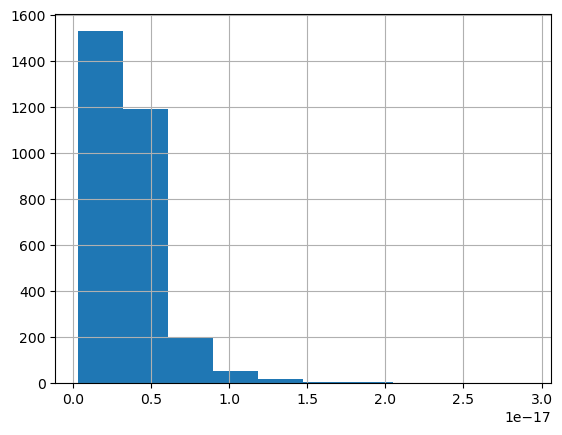

In [14]:
df_pwyx.strength.hist()
plt.show()

In [17]:
df_pwyx

,pair,strength
24,"(PWY3O-19, PWY3O-450)",2.917664e-17
2914,"(PWY-6614, PWY3O-50)",2.660864e-17
5,"(PWY3O-19, PWY3O-48)",2.579302e-17
394,"(PWY3O-862, PWY3O-450)",2.030449e-17
53,"(PWY3O-19, PWY0-662)",1.884610e-17
...,...,...
1549,"(PWY-5971-1, PWY-5084)",4.761331e-19
2077,"(PWY3O-8514, PWY-5084)",4.728456e-19
2332,"(PWY3O-4112, PWY-5760-1)",4.434608e-19
2757,"(PWY-5084, PWY3O-4120)",3.639409e-19


In [15]:
df_pwy_int.col2 *= 10**19

NameError: name 'df_pwy_int' is not defined

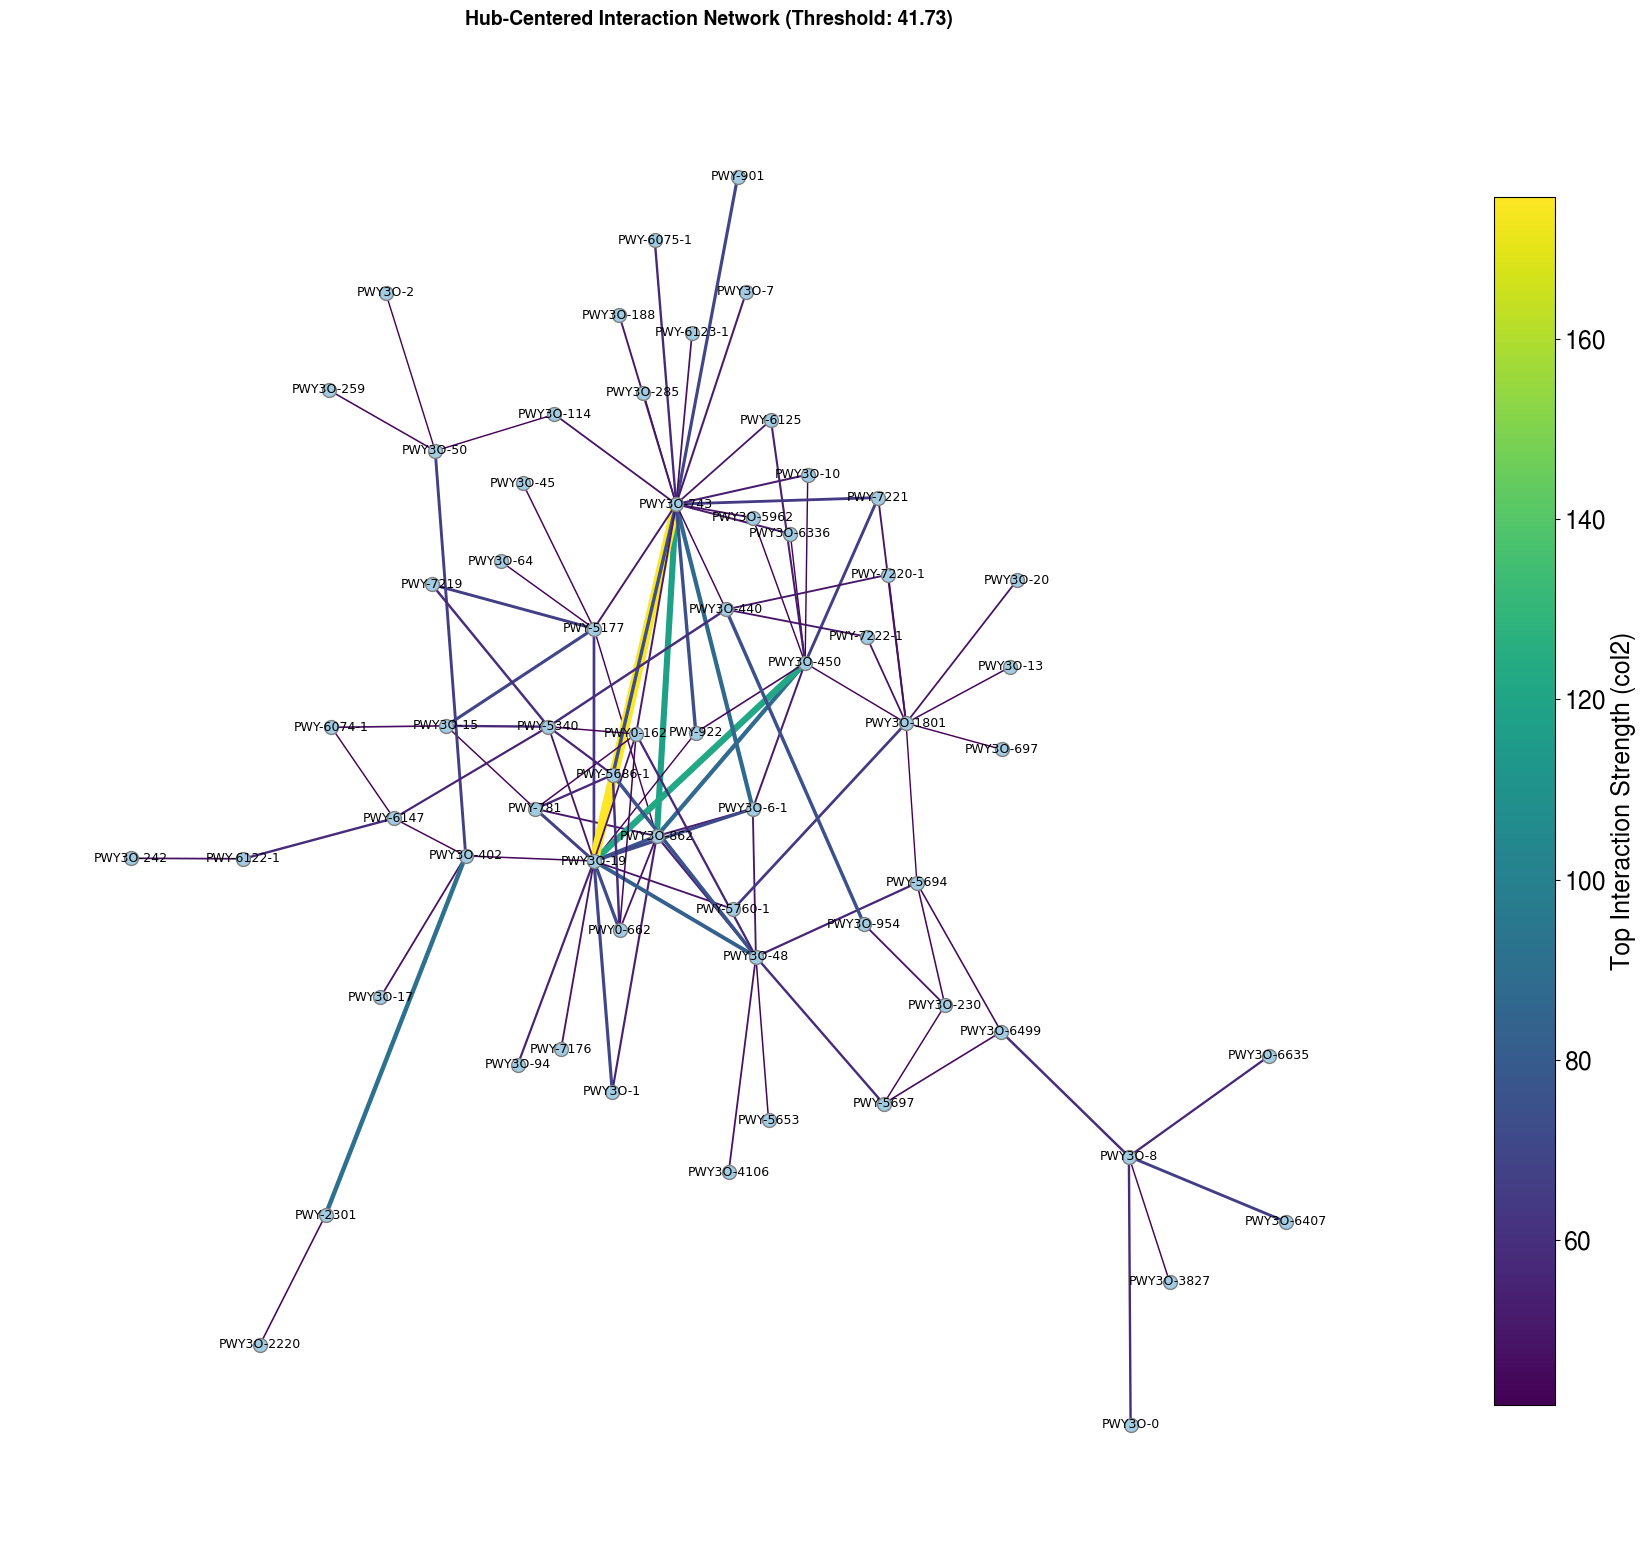

In [227]:
plot_interaction_network(df_pwy_int)